---   
 <img align="left" width="75" height="75"  src="https://upload.wikimedia.org/wikipedia/en/c/c8/University_of_the_Punjab_logo.png">

<h1 align="center">Department of Data Science</h1>
<h1 align="center">Course: Generative and Agentic AI</h1>

---
<h3><div align="right">Instructor: Muhammad Arif Butt, Ph.D.</div></h3>    

<br><br>
<h1 align="center">Lec-26: Fine-Tuning TinyLlama using <b>Unsloth</b></h1>

## **Learning Agenda of This Notebook**

1. Install Dependencies and Check your Runtime (only in Google Colab)
2. Dataset Curation
3. Configuration of Model, Dataset, LoRA Adapters, and Training Hyperparameters
4. Load Base Model + Tokenizer
5. Prepare Dataset
6. Configure and Inject LoRA Adapters
7. Configure Training Parameters
8. Train the Model (only on Google Colab)
9. Training Loss Plot
10. Save the Adapter Weights, Push to HF and Do Inference (`arif-butt/tinyllama-unsloth-lora-adapter`)
11. Merge Adapter Weights, Push to HF and Do Inference (`arif-butt/tinyllama-unsloth-merged`)
12. Generate GGUF and Push to to HF and Do Inverence via Ollama and Llama.cpp (`arif-butt/tinyllama-unsloth-gguf`)

# <span style='background :lightgreen' >Why Unsloth?</span>

| | Standard TRL | Unsloth + TRL |
|---|---|---|
| Training speed | Baseline | 2–5× faster |
| Memory usage | High | ~60% less VRAM |
| LoRA injection | via PEFT | Unsloth optimized kernels |
| GGUF export | Manual (llama.cpp) | Built-in `save_pretrained_gguf()` |
| Accuracy | Same | Same |

Unsloth replaces `transformers` for model loading and `peft` for LoRA injection — but `trl.SFTTrainer` is still used for training, exactly as before.


# <span style='background :lightgreen' >1. Install Dependencies and Check your Runtile (If in Google Colab)</span>

```
`unsloth` | Optimized model loading, LoRA injection, and GGUF export
`transformers` | Load pretrained models and tokenizers from HuggingFace
`peft`         | Provides `LoraConfig` and `get_peft_model()` for LoRA adapter injection
`datasets`     | Load datasets from HuggingFace Hub
`accelerate`   | Enables efficient GPU training
`trl`          | Training utilities
```

In [1]:
# Uncomment following code when running in Colab

!pip uninstall -y bitsandbytes 2>/dev/null || true

!pip install -q -U \
    unsloth \
    trl \
    datasets \
    transformers \
    accelerate

print("All packages installed successfully!")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.8/54.8 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 107.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 402.9/402.9 kB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 89.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 126.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.7/183.7 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 124.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22

In [1]:
# For the training part of this notebook, you need a GPU, rest you can run on your laptop
# If in Colab, Go to `Runtime > Change runtime type > T4 GPU`
import torch

if torch.cuda.is_available():
    print(f"GPU  : {torch.cuda.get_device_name(0)}")
    print(f"VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("No CUDA GPU detected. Running on CPU.")

No CUDA GPU detected. Running on CPU.


# <span style='background :lightgreen' >2. Dataset Curation</span>
- The dataset used for fine-tuning is a **custom synthetic Q&A dataset** built around **Dr. Muhammad Arif Butt** — covering his academic background, teaching experience, research interests, contact information and YouTube channel — curated specifically to teach the model to answer questions about him accurately and naturally.
## How the Dataset Was Curated
The dataset was created following a six-step curation pipeline — the same pipeline students can follow to build their own domain-specific datasets:
- **Step 1 — Collection:** Raw facts were gathered from Dr. Arif Butt's official website (https://arifbutt.me) and YouTube channel — covering all relevant topics including academic position, qualifications, research interests, courses taught and contact details
- **Step 2 — AI-Assisted Q&A Generation:** Each collected fact was fed into an AI model with a prompt instructing it to generate **3 to 5 different question variations per fact** — this rephrasing improves model generalisation by teaching it to answer the same fact regardless of how the question is phrased:
```
Fact: "Dr. Arif Butt is an Assistant Professor at PUCIT"

Generated question variations:
  "Who is Dr. Muhammad Arif Butt?"
  "Tell me about Dr. Arif Butt"
  "What is Arif Butt's current position?"
  "Where does Dr. Muhammad Arif Butt work?"
  "Which university does Dr. Arif Butt teach at?"
```
- **Step 3 — Cleaning and Validation:** All generated Q&A pairs were reviewed to remove duplicates, fix factual inaccuracies, ensure consistent tone and style, and discard any incomplete or low quality examples — human review of every example is critical at this stage since AI-generated data can contain subtle errors
- **Step 4 — Formatting:** Each Q&A pair was structured into the **ChatML messages format** required by TinyLlama — this is not optional — the model was pre-trained on this exact format and will only respond correctly if fine-tuning data matches it:
```json
{
  "messages": [
    {"role": "user",      "content": "Who is Dr. Muhammad Arif Butt?"},
    {"role": "assistant", "content": "Dr. Muhammad Arif Butt is an Assistant Professor
                                      at the Department of Data Science,
                                      University of the Punjab..."}
  ]
}
```
- **Step 5 — Balancing:** Questions were distributed evenly across all topics — academic background, teaching experience, research interests, contact information and YouTube channel — preventing the model from becoming biased toward one topic while forgetting others
- **Step 6 — Upload to HuggingFace Hub:** The final cleaned and formatted dataset was saved as `.jsonl` and uploaded as a public dataset so it can be loaded in one line anywhere:

#### 🔗 **Dataset:** [arif-butt/arifbutt_dataset](https://huggingface.co/datasets/arif-butt/arifbutt_dataset)


## Students should build their own synthetic Dataset
- Pick any domain, a product, a company or a public figure.
- Collect facts from public sources;  websites, Wikipedia, official pages.
- Feed the facts into an AI model and ask it to generate 3 to 5 question variations per fact.
- Review and clean all generated pairs, remove duplicates and fix any inaccuracies.
- Format each pair as ChatML `messages` and save as `.jsonl`.
- Upload to HuggingFace Hub using `dataset.push_to_hub()` and your dataset is ready to use.

# <span style='background :lightgreen' >3. Configuration of Model, Dataset, LoRA Adapters, and Training  Hyperparameters</span>

- The code cell below defines the base model, dataset source, output directories, LoRA configuration, and training hyperparameters required for fine-tuning.
- It centralizes all experiment settings such as batch size, learning rate, and sequence length to make the training pipeline easy to configure and reproduce.
- Finally, it creates the required output directories for saving LoRA adapters and the merged final model.

In [2]:
import torch                 # PyTorch library for tensor operations and GPU acceleration
import gc                    # garbage collector for freeing up memory during training
from unsloth import FastLanguageModel    # Unsloth's optimized model loading with faster training kernels
from datasets import load_dataset        # HuggingFace dataset loading utility
from trl import SFTTrainer, SFTConfig    # TRL's supervised fine-tuning trainer and config

BASE_MODEL_ID   = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"    # base model identifier from HuggingFace Hub
HF_DATASET_NAME = "arif-butt/arifbutt_dataset"            # dataset identifier for fine-tuning
ADAPTER_OUTPUT_DIR      = "./tinyllama-unsloth-lora-adapter"      # directory to save LoRA adapter weights
MERGED_OUTPUT_DIR      = "./tinyllama-unsloth-merged"                    # directory to save merged model


SYSTEM_PROMPT = (                                  # system instruction prepended to every conversation
    "You are a helpful assistant."                 # sets model behavior to be helpful and assistant-like
)

# LoRA Hyperparameters
LORA_R       = 16                                 # rank of LoRA adapter matrices — controls trainable parameter count
LORA_ALPHA   = 32                                 # scaling factor for LoRA updates — alpha/r = 2.0
LORA_DROPOUT = 0.05                               # dropout probability for LoRA layers — prevents overfitting

# Training Hyperparameters
NUM_EPOCHS     = 3                               # number of complete passes through training dataset
BATCH_SIZE     = 1                               # samples per GPU per forward/backward pass
GRAD_ACCUM     = 2                               # batches to accumulate before weight update
LEARNING_RATE  = 2e-4                            # optimizer step size for parameter updates
MAX_SEQ_LENGTH = 256                             # maximum tokens per training sample
WARMUP_steps  = 10                               # initial steps where learning rate increases gradually
SAVE_STEPS     = 50                              # steps between saving model checkpoints
LOGGING_STEPS  = 10                              # steps between logging training metrics
SEED           = 42                              # fixed random seed for reproducibility

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


# <span style='background :lightgreen' >4. Load Base Model + Tokenizer</span>

**Unsloth replaces `transformers` here.**

`FastLanguageModel.from_pretrained()` loads the model with:
- Unsloth's optimized CUDA kernels — 2–5× faster than standard transformers loader
- Automatic fp16 precision
- `max_seq_length` set at load time — no truncation surprises during training


In [3]:
print("Loading TinyLlama with Unsloth...")

# FastLanguageModel.from_pretrained loads both model & tokenizer together
# Unsloth's implementation provides 2-5x faster training and 70% less memory usage
# Optimized specifically for LoRA fine-tuning with fused kernels
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=BASE_MODEL_ID,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=None,           # let Unsloth auto-select based on available GPU memory
    load_in_4bit=False,    # set to True only for QLoRA (4-bit quantization); False required for standard LoRA with Unsloth
)

print("Model + Tokenizer ready!")
print(f"Max sequence length : {MAX_SEQ_LENGTH}")
print(f"Model dtype         : {next(model.parameters()).dtype}")

Loading TinyLlama with Unsloth...
==((====))==  Unsloth 2026.3.15: Fast Llama patching. Transformers: 5.3.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/754 [00:00<?, ?B/s]

...

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/438 [00:00<?, ?B/s]

Unsloth: Will load unsloth/tinyllama-chat as a legacy tokenizer.


Model + Tokenizer ready!
Max sequence length : 256
Model dtype         : torch.float16


# <span style='background :lightgreen' >5. Prepare Dataset</span>

In [4]:
from datasets import load_dataset
from dotenv import load_dotenv      # Imports the load_dotenv function, which loads environment variables from a .env file into your Python environment.
from huggingface_hub import login   # Imports the login() function that allows you to authenticate with the Hugging Face Hub using an access token.
import os                           # Imports Python’s built-in os module so you can access environment variables (like your HF token).

# The following login() call is only necessary if you want to access private repos, or to use private models or to push models/datasets
'''
load_dotenv('../keys/.env', override=True)
hf_token = os.getenv('HF_TOKEN')
login(token=hf_token)
'''

raw_dataset = load_dataset("arif-butt/arifbutt_dataset")
print("✓ Dataset loaded successfully!")
raw_dataset

drarif.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/1926 [00:00<?, ? examples/s]

✓ Dataset loaded successfully!


DatasetDict({
    train: Dataset({
        features: ['messages'],
        num_rows: 1926
    })
})

In [5]:
print("\nSample examples from the training split:\n")
for idx in range(5):
    sample = raw_dataset["train"][idx]
    print(f"Example {idx + 1}: {sample}")


Sample examples from the training split:

Example 1: {'messages': [{'role': 'user', 'content': 'Who is Dr. Muhammad Arif Butt?'}, {'role': 'assistant', 'content': 'Dr. Muhammad Arif Butt is an accomplished Assistant Professor at the Department of Data Science, University of the Punjab (PU), Lahore, Pakistan. He has over 33 years of experience in teaching and management, with expertise in cybersecurity, operating systems, and artificial intelligence.'}]}
Example 2: {'messages': [{'role': 'user', 'content': 'Tell me about Dr. Arif Butt'}, {'role': 'assistant', 'content': "Dr. Muhammad Arif Butt is an Assistant Professor at Punjab University's Data Science department. He's a technology entrepreneur and cybersecurity expert with 33+ years of experience, combining academic excellence with industry innovation."}]}
Example 3: {'messages': [{'role': 'user', 'content': "What is Arif butt's current position?"}, {'role': 'assistant', 'content': 'Dr. Muhammad Arif Butt currently serves as an Assi

## Format the [arif-butt/arifbutt_dataset](https://huggingface.co/datasets/arif-butt/arifbutt_dataset)
- The dataset uses a `messages` format — a list of `{role, content}` dicts. We must convert each example into the exact ChatML string format TinyLlama expects:

```
<|system|>
You are a helpful assistant.</s>
<|user|>
Who is Dr. Arif Butt?</s>
<|assistant|>
Dr. Muhammad Arif Butt is an Assistant Professor...</s>
```

**Steps inside `format_example()`:**
1. Detects dataset layout (messages / instruction+output / plain text)
2. Builds the correct ChatML string for each example
3. `dataset.map()` applies this to every example in the dataset

**Tokenization:**
- `labels = input_ids` — for causal LM, the model learns to predict the next token, so labels are the same as inputs
- `truncation=True` — examples longer than `MAX_SEQ_LENGTH` are cut off
- `padding="max_length"` — shorter examples are padded to the same length

In [6]:
################# CONVERT DATASET ROWS INTO TINYLLAMA CHAT FORMAT ###############################

# ── Format Function ───────────────────────────────────────────────────────────
def format_example(example):
    """Format messages into TinyLlama ChatML conversation."""
    text = "<|system|>\nYou are a helpful assistant.</s>\n"  # start every conversation with a system prompt that sets the assistant's behaviour and persona
    for msg in example["messages"]:         # iterate over each message in the conversation — each message is a dict with "role" and "content" keys
        role    = msg["role"]               # extract the role of the message sender — either "user" or "assistant"
        content = msg["content"].strip()    # extract and clean the message text — strip() removes any leading or trailing whitespace
        if role == "user":
            text += f"<|user|>\n{content}</s>\n"        # wrap user message in TinyLlama's ChatML user tags — <|user|> opens and </s> closes the turn
        elif role == "assistant":
            text += f"<|assistant|>\n{content}</s>\n"   # wrap assistant message in TinyLlama's ChatML assistant tags — model learns to generate text between these tags
    return {"formatted_text": text}   # return the fully formatted conversation as a new column called "formatted_text" that replaces the original "messages" column

# ── Tokenize Function ─────────────────────────────────────────────────────────
def tokenize(example):
    """Convert formatted text into token IDs."""
    result = tokenizer(
                    example["formatted_text"],      # pass the ChatML formatted conversation string to the tokenizer for conversion to token IDs
                    truncation=True,                # if the formatted text exceeds MAX_SEQ_LENGTH tokens — cut it off and keep only the first MAX_SEQ_LENGTH tokens
                    max_length=MAX_SEQ_LENGTH,      # set the fixed sequence length to 512 — all sequences will be either truncated or padded to exactly this length
                    padding="max_length",           # if the formatted text is shorter than MAX_SEQ_LENGTH — pad it on the right with the pad token (EOS token) to reach exactly 512 tokens
                )
    result["labels"] = result["input_ids"].copy()   # for causal language model training the labels are identical to input_ids — the model learns to predict the next token by shifting input one position right internally
    return result   # return tokenized output containing input_ids, attention_mask and labels — all of length MAX_SEQ_LENGTH

# ── Apply Formatting ──────────────────────────────────────────────────────────
formatted_dataset = raw_dataset.map(
                        format_example,                                    # apply the format_example function to every row in the dataset
                        remove_columns=raw_dataset["train"].column_names,  # drop all original columns (messages, etc.) and keep only the new "formatted_text" column
                        )

# ── Tokenize Dataset ──────────────────────────────────────────────────────────
tokenized_dataset = formatted_dataset.map(
                        tokenize,                          # apply the tokenize function to every row in the formatted dataset
                        batched=True,                      # process multiple examples at once for significantly faster tokenization
                        remove_columns=["formatted_text"], # drop the "formatted_text" string column — no longer needed after tokenization
                        )

# ── Train / Eval Split ────────────────────────────────────────────────────────
spl = tokenized_dataset["train"].train_test_split(test_size=0.1, seed=SEED)  # randomly split the tokenized training data into 90% train and 10% evaluation using fixed seed for reproducibility

train_dataset = spl["train"]  # assign the 90% split to train_dataset — used to update LoRA adapter weights during training
eval_dataset  = spl["test"]   # assign the 10% split to eval_dataset  — used to monitor loss on unseen examples during training without updating any weights

print("Dataset prepared")
print(f"Train examples:\n {train_dataset}")  # print the train dataset object showing number of examples, column names and data types
print(f"Eval examples:\n {eval_dataset}")    # print the eval  dataset object showing number of examples, column names and data types

Map:   0%|          | 0/1926 [00:00<?, ? examples/s]

Map:   0%|          | 0/1926 [00:00<?, ? examples/s]

Dataset prepared
Train examples:
 Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 1733
})
Eval examples:
 Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 193
})


In [7]:
# Print fully tokenized training example that will be fed to the model during fine-tuning of TinyLlama-1.1B-Chat-v1.0.
print(train_dataset[0])

{'input_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 529, 29989, 5205, 29989, 29958, 13, 3492, 526, 263, 8444, 20255, 29889, 2, 13, 29966, 29989, 1792, 29989, 29958, 13, 25125, 4942, 29889, 826, 361, 505, 263, 6189, 29257, 3236, 373, 670, 14711, 8242, 29973, 2, 13, 29966, 29989, 465, 22137, 29989, 29958, 13, 8241, 29892, 4942, 29889, 29610, 826, 361, 1205, 29873, 29915, 29879, 14711, 8242, 525, 29931, 799, 29876, 2973, 826, 361, 29915, 756, 263, 6189, 29257, 3236, 411, 29871, 29945, 19707, 3625, 363, 8041

> **input_ids:** 1 → start-of-sequence token, 13 → newline token, 2 → end-of-sequence or padding token (After the real text ends, the sequence is padded because we used `MAX_SEQ_LENGTH = 512` and `padding = "max_length"`

> **attention_mask:** This tensor tells the transformer which tokens to pay attention to. 1 →  real conversation tokens, 0 →  padding and transformer ignores tokens where mask = 0

> **labels:** For causal language modeling, the labels are simply input_ids. During training the model learns: `Predict token_(t+1) from token_1 ... token_t`

In [8]:
sample = train_dataset[0]
print("Decoded text:\n")
print(tokenizer.decode(sample["input_ids"]))

Decoded text:

<unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><s> <|system|>
You are a helpful assistant.</s>
<|user|>
Does Dr. Arif have a Machine Learning course on his Y

# <span style='background :lightgreen' >6. Configure and Inject LoRA Adapters</span>
**Unsloth replaces `peft` here.**

`FastLanguageModel.get_peft_model()` injects optimized LoRA adapter matrices directly into the model using Unsloth's faster backward pass kernels — replacing the standard PEFT approach.

**`target_modules`** — which layers to adapt:

| Module | Layer Type |
|---|---|
| `q_proj`, `k_proj`, `v_proj`, `o_proj` | Attention — Query, Key, Value, Output |
| `gate_proj`, `up_proj`, `down_proj` | MLP Feed-Forward layers |

**`use_gradient_checkpointing = "unsloth"`** — Unsloth's custom gradient checkpointing saves additional VRAM beyond standard PyTorch checkpointing.

In [9]:
print("Injecting LoRA adapters with Unsloth...")

# Using Unsloth's optimized get_peft_model instead of standard PEFT's get_peft_model
# WHY? Standard PEFT's get_peft_model would use generic LoRA implementation with slower kernels
# Unsloth's version uses fused kernels and memory optimizations that are 2-5x faster
# Standard approach: model = get_peft_model(model, lora_config)  # slower, generic implementation
# Unsloth approach: direct method call with optimized parameters
model = FastLanguageModel.get_peft_model(
    model,
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=0.0,          # must be 0 for Unsloth fast kernels (standard PEFT allows non-zero)
    bias="none",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    use_gradient_checkpointing="unsloth",  # Unsloth-specific checkpointing (standard uses True/False)
    random_state=SEED,
)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters : {trainable:,}")
print(f"Total parameters     : {total:,}")
print(f"Trainable %          : {100 * trainable / total:.2f}%")

Injecting LoRA adapters with Unsloth...


Unsloth 2026.3.15 patched 22 layers with 22 QKV layers, 22 O layers and 22 MLP layers.


Trainable parameters : 12,615,680
Total parameters     : 1,112,664,064
Trainable %          : 1.13%


# <span style='background :lightgreen' >7. Configure Training</span>
- The following code cell defines the entire training behavior for the fine-tuning process:
    - training duration
    - batch sizes
    - optimizer
    - learning rate schedule
    - checkpointing
    - evaluation
    - reproducibility
- It acts as the central configuration object for the training loop used by the Hugging Face Trainer

In [10]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"          # disables tokenizer parallelism to avoid deadlocks during training

training_args = SFTConfig(
    output_dir=ADAPTER_OUTPUT_DIR,                              # directory where training checkpoints and logs are saved
    num_train_epochs=NUM_EPOCHS,                        # number of complete passes through the entire training dataset
    per_device_train_batch_size=BATCH_SIZE,             # number of training samples processed per GPU in each step
    gradient_accumulation_steps=GRAD_ACCUM,             # number of steps to accumulate gradients before weight update
    learning_rate=LEARNING_RATE,                        # step size for optimizer updates during training
    warmup_steps=WARMUP_steps,                          # number of initial steps where learning rate increases gradually
    lr_scheduler_type="cosine",                         # learning rate schedule that decreases LR using cosine decay
    dataloader_num_workers=0,                           # number of subprocesses for data loading (0 = main process)
    fp16=False,                                         # disables FP16 mixed precision training
    bf16=False,                                         # disables BF16 precision (not supported on older GPUs)
    logging_steps=LOGGING_STEPS,                        # number of steps between logging training metrics
    eval_strategy="steps",                              # specifies that evaluation occurs periodically during training
    eval_steps=50,                                      # number of steps between evaluation runs on validation dataset
    save_strategy="steps",                              # specifies that checkpoints are saved periodically during training
    save_steps=50,                                      # number of training steps between saving model checkpoints
    load_best_model_at_end=True,                        # automatically reload the checkpoint with the best evaluation metric
    metric_for_best_model="eval_loss",                  # metric used to determine which checkpoint is the best model
    weight_decay=0.01,                                  # regularization parameter that penalizes large weights
    save_total_limit=2,                                 # maximum number of checkpoints to keep (older ones are deleted)
    max_length=MAX_SEQ_LENGTH,                          # maximum number of tokens allowed per training sample
    dataset_text_field="text",                          # name of the field in the dataset containing the training text
    seed=SEED,                                          # fixed random seed to ensure reproducible training results
    dataset_num_proc=1,                                 # number of processes for dataset preprocessing
)

print("Training config ready!")                         # confirmation that training configuration is complete
print(f"Epochs               : {NUM_EPOCHS}")           # display number of training epochs configured
print(f"Effective batch size : {BATCH_SIZE * GRAD_ACCUM}")  # display actual batch size after gradient accumulation
print(f"Learning rate        : {LEARNING_RATE}")        # display the learning rate being used for training

Training config ready!
Epochs               : 3
Effective batch size : 2
Learning rate        : 0.0002


# <span style='background :lightgreen' >8. Train the Model (only on Google Colab)</span>
**What happens inside `trainer.train()`:**
```
For each batch:
  1. Forward pass   — feed tokens through model, get predictions
  2. Loss           — measure how wrong predictions are (cross-entropy)
  3. Backprop       — calculate gradients
  4. Update         — adjust only LoRA adapter weights
  5. Repeat
```

**How to read the training table:**
```
`Step`            | How many batches have been processed
`Training Loss`   | Loss on training data — should go down
`Validation Loss` | Loss on unseen data — should follow training loss
```
**Diagnosing your training:**
-  Both losses going down together → healthy training
-  Train loss low, eval loss rising → overfitting → reduce epochs
-  Both losses staying high → underfitting → increase epochs or LORA_R

**The estimated time to run this code cell on a Google Colab T4 GPU is approximately 30 minutes.You can see total steps, Train loss and Runtime in the output of this cell**

In [ ]:
# Using SFTTrainer (Supervised Fine-Tuning Trainer) from TRL library
# WHY SFTTrainer with Unsloth?
# - SFTTrainer is specifically designed for instruction fine-tuning of LLMs
# - It automatically handles:
#   1. Formatting prompts with chat templates
#   2. Masking loss on prompt tokens (only compute loss on responses)
#   3. Packing sequences for efficiency
#   4. Managing padding and attention masks
# - Unsloth integrates seamlessly with SFTTrainer - no special modifications needed
# - Standard alternative would be Trainer from transformers, but SFTTrainer provides:
#   * Built-in support for instruction datasets
#   * Automatic prompt formatting
#   * Better handling of conversational data
trainer = SFTTrainer(
    model=model,                    # Unsloth model with LoRA adapters already injected
    processing_class=tokenizer,     # tokenizer for encoding text (SFTTrainer expects processing_class not tokenizer in newer versions)
    train_dataset=train_dataset,    # ← updated
    eval_dataset=eval_dataset,
    args=training_args
)

print("Training started...")
trainer.train()                     # Unsloth's optimizations work automatically through the model
print("Training complete!")

# <span style='background :lightgreen' >9. Training Loss Plot</span>
This cell plots the training and evaluation loss as a line chart so you can visually diagnose training health.

- 🔵 **Blue line** — Training loss
- 🔴 **Red line** — Validation loss

Both lines going down smoothly and staying close together = healthy training. The plot is also saved as `loss_curve.png`.

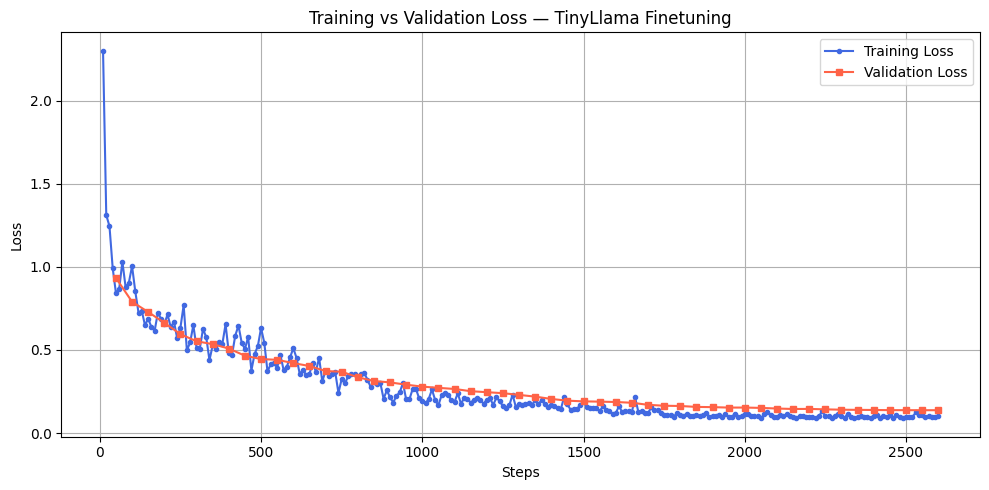

Graph saved → loss_curve.png


In [ ]:
import matplotlib.pyplot as plt

logs = trainer.state.log_history

train_loss = [(x['step'], x['loss'])      for x in logs if 'loss' in x and 'eval_loss' not in x]
eval_loss  = [(x['step'], x['eval_loss']) for x in logs if 'eval_loss' in x]

plt.figure(figsize=(10, 5))
plt.plot(*zip(*train_loss), label='Training Loss',   color='royalblue', marker='o', markersize=3)
plt.plot(*zip(*eval_loss),  label='Validation Loss', color='tomato',    marker='s', markersize=4)
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss — TinyLlama Finetuning')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150)
plt.show()
print("Graph saved → loss_curve.png")

# <span style='background :lightgreen' >10. Save the Adapter Weights, Push to HF and Do Inference</span>

## a. Save the Adapter Weights
- After training we save **only the LoRA adapter weights** (48.16 MB), not the full merged model weights which will be greater than 2.2 GB.
- The saved folder contains:
    - `adapter_config.json`       — LoRA architecture definition
    - `adapter_model.safetensors` — the actual trained weights around 30 MB only
    - `tokenizer files`           — if tokenizer saved alongside adapters
- Can be pushed on hugging face hub
- The advantages of this option are:
    -  The size of files to be saved is small
    -  If pushed on HF hub, any one having TinyLlama base can download the adapter weights and use them with base model

####  After `model.save_pretrained()` and `tokenizer.save_pretrained()`, the ADAPTER_OUTPUT_DIR (`./tinyllama-peft-lora-adapters`) contains:

| File | Size | Contents |
|---|---|---|
| `adapter_model.safetensors` | 48.16 MB | The **LoRA adapter weights only** — the small delta matrices (A & B) injected into the base model layers. Does **not** contain base model weights. |
| `adapter_config.json` | 737 B | LoRA configuration: rank (`r`), alpha, dropout, target modules, task type. Needed to reconstruct the PEFT model. |
| `tokenizer.json` | 1.76 MB | Fast tokenizer data — full vocabulary, BPE merge rules, and special token mappings. |
| `tokenizer_config.json` | 1.3 KB | Tokenizer metadata — class name, special tokens (`bos_token`, `eos_token`, `pad_token`), padding side, etc. |
| `tokenizer.model` | 488.0 KB | The raw SentencePiece model file used by the slow tokenizer for subword tokenization. |
| `special_tokens_map.json` | 437 B | Maps special token names (`bos_token`, `eos_token`, `unk_token`) to their string values. |
| `checkpoint-350/` | 4.0 KB | Mid-training checkpoint saved automatically at step 350. |
| `checkpoint-400/` | 4.0 KB | Mid-training checkpoint saved automatically at step 400 (latest). |
| `README.md` | 5.0 KB | Auto-generated model card describing the adapter. |



>- **Limitation of this option is, the uploaded adapter weights cannot be used as a standalone model, for which you have to merge**

In [ ]:
# Save LoRA Adapter Weights Only (Unsloth)

# Save adapter weights and tokenizer after training
print("Saving LoRA adapter weights...")
model.save_pretrained(ADAPTER_OUTPUT_DIR)               # saves adapter_config.json and adapter_model.safetensors
tokenizer.save_pretrained(ADAPTER_OUTPUT_DIR)           # saves tokenizer files for reuse

print(f"Adapter saved to: {ADAPTER_OUTPUT_DIR}")
print(f"Size: ~48 MB (adapter weights only)")


In [ ]:
import os

if os.path.exists(ADAPTER_OUTPUT_DIR):
    print(f"Files saved in: {ADAPTER_OUTPUT_DIR}\n")
    for fname in sorted(os.listdir(ADAPTER_OUTPUT_DIR)):
        fpath = os.path.join(ADAPTER_OUTPUT_DIR, fname)
        size  = os.path.getsize(fpath)
        if size >= 1_048_576:
            size_str = f"{size / 1_048_576:.2f} MB"
        elif size >= 1024:
            size_str = f"{size / 1024:.1f} KB"
        else:
            size_str = f"{size} B"
        print(f"  {fname:<40} {size_str}")
else:
    print(f"Directory '{ADAPTER_OUTPUT_DIR}' not found.")
    print("Run the training and save steps first before listing files.")

## b. Push the Files to HuggingFace Hub
After merging, push the standalone model to HuggingFace Hub so it can be loaded from anywhere without needing local files.

**Before pushing, you need a Write token:**  
Go to → **huggingface.co → Profile → Settings → Access Tokens → New Token → Type: Write**

In [ ]:

# ── Push Adapter to HuggingFace Hub ─────────────────────────────────────────────────────────

import os
from huggingface_hub import HfApi, create_repo, login
from getpass import getpass

# Login to HuggingFace
print("🔐 Login to HuggingFace Hub...")
hf_token = getpass("Enter your Hugging Face API token: ")
login(token=hf_token)

# Configure repository
REPO_ID = "arif-butt/tinyllama-unsloth-lora-adapter"  # change to your username/repo-name
ADAPTER_OUTPUT_DIR = "./tinyllama-unsloth-lora-adapter"


# Create repo if it doesn't exist
print(f"📦 Creating/checking repository: {REPO_ID}")
create_repo(
    repo_id=REPO_ID,
    repo_type="model",
    exist_ok=True
)

# Upload adapter files
print("📤 Uploading adapter files to HuggingFace Hub...")
api = HfApi()
api.upload_folder(
    folder_path=ADAPTER_OUTPUT_DIR,
    repo_id=REPO_ID,
    repo_type="model",
    path_in_repo="",                                   # upload to root
)

print(f"Adapter uploaded successfully!")
print(f"https://huggingface.co/{REPO_ID}")

## c. Inference with loading LoRa Adapter from hugging face

In [ ]:
# ── Inference with Unsloth + LoRA Adapter from Hub ────────────────────────────

import torch
from unsloth import FastLanguageModel
from peft import PeftModel
from transformers import pipeline

# ── Model Configuration
BASE_MODEL_ID = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"              # base model identifier
ADAPTER_REPO = "arif-butt/tinyllama-unsloth-lora-adapter"         # your adapter repo on HF Hub

# ── Load Base Model with Unsloth Optimizations
print("Loading base model with Unsloth...")
base_model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=BASE_MODEL_ID,                                     # base model to load
    max_seq_length=512,                                           # maximum sequence length
    dtype=torch.float16,                                          # use float16 for efficiency
    load_in_4bit=False,                                           # disable 4-bit quantization
    device_map="auto",                                            # auto-distribute layers
    trust_remote_code=True,                                       # allow custom model code
)
print("Base model loaded")

# ── Load and Attach LoRA Adapters from Hub
print("Loading LoRA adapters from HuggingFace Hub...")
model = PeftModel.from_pretrained(
    base_model,                                                   # base model with Unsloth optimizations
    ADAPTER_REPO,                                                 # HuggingFace repo with adapter weights
    device_map="auto",                                            # keep same device mapping
)
print("Adapters attached")

# ── Create Text Generation Pipeline
print("🔧 Creating pipeline...")
pipe = pipeline(
    "text-generation",                                            # text generation task
    model=model,                                                  # fine-tuned model
    tokenizer=tokenizer,                                          # matching tokenizer
    device_map="auto",                                            # use same device as model
)

In [ ]:
# Single Prompt Test
prompt = "Q: Name all the courses Arif butt teach?\nA:"          # test prompt

print("\n" + "="*50)
print(f"Prompt: {prompt}")

output = pipe(
    prompt,                                                       # input prompt
    max_new_tokens=100,                                           # maximum new tokens to generate
    temperature=0.2,                                              # low temp for factual answers
    do_sample=True,                                               # enable sampling
    pad_token_id=tokenizer.eos_token_id,                          # prevent infinite generation
)

print(f"Response: {output[0]['generated_text']}")
print("="*50)

### Before merging, we free up VRAM by deleting the trainer and model from memory. This prevents Out-of-Memory errors when reloading the base model for merging.

In [ ]:
import gc
import torch

del trainer
del model
gc.collect()
torch.cuda.empty_cache()

print("GPU memory cleared!")
if torch.cuda.is_available():
    print(f"Allocated : {torch.cuda.memory_allocated() / 1e9:.2f} GB")
    print(f"Reserved  : {torch.cuda.memory_reserved() / 1e9:.2f} GB")

# <span style='background :lightgreen' >11. Merge Adapter Weights, Push to HF and Do Inference</span>

## a. Save the Complete Merged  Model
- Now that we have saved the adapter weights, we can now create the final standalone model by merging the LoRA adapters into the base model.
- Before merge → need both base model + adapter files to run
- After merge → one single file, no PEFT library needed at inference time
- **What Gets Saved After Both Steps:**
```
./tinyllama-peft-lora-adapters/              ← ADAPTER_OUTPUT_DIR
  ├── adapter_config.json               ← LoRA config (r=16, alpha=32, target modules)
  ├── adapter_model.safetensors         ← LoRA adapter weights only (~16 MB)
  ├── tokenizer.json                    ← full tokenizer
  ├── tokenizer_config.json             ← tokenizer settings
  ├── special_tokens_map.json           ← special tokens
  └── tokenizer.model                   ← tokenizer binary

./tinyllama-peft-merged/                     ← MERGED_OUTPUT_DIR
  ├── config.json                       ← full model architecture config
  ├── generation_config.json            ← default generation settings
  ├── model.safetensors                 ← FULL merged weights (~2.2 GB)
  ├── tokenizer.json                    ← full tokenizer
  ├── tokenizer_config.json             ← tokenizer settings
  ├── special_tokens_map.json           ← special tokens
  └── tokenizer.model                   ← tokenizer binary
```

In [ ]:
# ── Merge LoRA Adapters and Save Complete Merged Model (Unsloth)

import torch
import os
from unsloth import FastLanguageModel
from peft import PeftModel

# ── Configuration
BASE_MODEL_ID = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"              # base model identifier
ADAPTER_OUTPUT_DIR = "./tinyllama-unsloth-lora-adapter"           # directory with saved adapter weights
MERGED_OUTPUT_DIR = "./tinyllama-unsloth-merged"                  # directory to save merged model

# ── Load Base Model with Unsloth Optimizations
print("Loading base model with Unsloth...")
base_model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=BASE_MODEL_ID,                                     # base model to load
    max_seq_length=512,                                           # maximum sequence length
    dtype=torch.float16,                                          # use float16 for efficiency
    load_in_4bit=False,                                           # disable 4-bit quantization
    device_map="auto",                                            # auto-distribute layers
)
print("Base model loaded")

# ── Load and Attach LoRA Adapters
print("Loading LoRA adapters...")
model = PeftModel.from_pretrained(
    base_model,                                                   # base model with Unsloth optimizations
    ADAPTER_OUTPUT_DIR,                                           # directory with adapter weights
)
print("Adapters attached")

# ── Merge Adapters into Base Model (Unsloth Method)
print("Merging adapters into base model...")
merged_model = model.merge_and_unload()                           # permanently bake adapters into base weights
print("Adapters merged successfully")

# ── Save Complete Merged Model
print("Saving complete merged model...")

# Save merged model weights and config
merged_model.save_pretrained(
    MERGED_OUTPUT_DIR,                                                   # output directory for merged model
    save_embedding_layers=True,                                   # save embedding layer weights
)

# Save tokenizer files
tokenizer.save_pretrained(MERGED_OUTPUT_DIR)                             # saves all tokenizer files

print(f"Merged model saved to: {MERGED_OUTPUT_DIR}")


Saving merged fp16 model...
Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
Checking cache directory for required files...


Unsloth: Copying 1 files from cache to `./tinyllama-unsloth-lora-adapter`: 100%|██████████| 1/1 [00:20<00:00, 20.33s/it]


Successfully copied all 1 files from cache to `./tinyllama-unsloth-lora-adapter`
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [00:41<00:00, 41.59s/it]


Unsloth: Merge process complete. Saved to `/content/tinyllama-unsloth-lora-adapter`
Merged model saved → ./tinyllama-unsloth-lora-adapter


## b. Push the Merged model Files to HuggingFace Hub

After merging, push the standalone model to HuggingFace Hub so it can be loaded from anywhere without needing local files.

**Before pushing, you need a Write token:**  
Go to → **huggingface.co → Profile → Settings → Access Tokens → New Token → Type: Write**

In [ ]:
# ── Push Complete Merged Model to HuggingFace Hub

import os
from huggingface_hub import HfApi, create_repo, login
from getpass import getpass

# ── Configuration
MERGED_MODEL_REPO = "arif-butt/tinyllama-unsloth-merged"          # repo for merged model
MERGED_OUTPUT_DIR = "./tinyllama-unsloth-merged"                          # local merged model path

# ── Login
print("Login to HuggingFace Hub...")
hf_token = getpass("Enter your Hugging Face API token: ")
login(token=hf_token)

# ── Create Repository
print(f"Creating repository: {MERGED_MODEL_REPO}")
create_repo(
    repo_id=MERGED_MODEL_REPO,
    repo_type="model",
    exist_ok=True,
)

# ── Upload Merged Model Files
print("Uploading merged model files...")
api = HfApi()
api.upload_folder(
    folder_path=MERGED_OUTPUT_DIR,
    repo_id=MERGED_MODEL_REPO,
    repo_type="model",
    path_in_repo="",
)

print(f"Merged model uploaded successfully!")
print(f"🔗 https://huggingface.co/{MERGED_MODEL_REPO}")
print("\n📝 Now anyone can load it with:")
print(f"   model = AutoModelForCausalLM.from_pretrained('{MERGED_MODEL_REPO}')")

## c. Inference by loading merged model from hugging face

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
import torch

# 1. Model Repo - HuggingFace repository containing merged model (base + LoRA weights combined)
MERGED_MODEL_ID = "arif-butt/tinyllama-peft-merged"

# 2. Load tokenizer - converts text to token IDs and back
# Tokenizer config (padding, special tokens) is preserved from training
tokenizer = AutoTokenizer.from_pretrained(MERGED_MODEL_ID)

# 3. Load merged model (standalone) - no Unsloth/PEFT needed after merging
# AutoModelForCausalLM automatically detects architecture (Llama, GPT, etc.)
model = AutoModelForCausalLM.from_pretrained(
    MERGED_MODEL_ID,
    torch_dtype=torch.float16,  # use half precision for GPU efficiency (reduces memory by ~50%)
    device_map="auto"           # automatically use GPU if available, falls back to CPU
)

# 4. Create pipeline - high-level API for text generation
# Handles tokenization, model inference, and decoding in one interface
pipe = pipeline(
    task="text-generation",      # specifies this is a causal language model task
    model=model,                  # the loaded merged model
    tokenizer=tokenizer,          # tokenizer for encoding/decoding
    return_full_text=False        # only return the model-generated answer (exclude input prompt)
)

In [ ]:
# 5. Example prompt
prompt = "Q: Who is Dr. Arif Butt?\nA:"

output = pipe(
    prompt,
    max_new_tokens=150,
    do_sample=False,           # deterministic/factual output
    repetition_penalty=1.1
)

# 6. Print answer
print(output[0]["generated_text"].strip())

###  **Files Uploaded to HuggingFace Hub**

After pushing the merge model to hugging face, your repository on HuggingFace Hub will contain:

```
your-username/tinyllama-drarif-finetuned/
├── model.safetensors          (~2.2 GB)  — Merged model weights (base + LoRA baked in). All neural network parameters in SafeTensors format.
├── config.json                (~713 B)   — Model architecture config: type (LlamaForCausalLM), hidden size, num layers, attention heads, vocab size.
├── tokenizer.json             (~1.84 MB) — Fast tokenizer: full vocabulary, BPE merge rules, special token mappings.
├── tokenizer_config.json      (~1.32 KB) — Tokenizer settings: class, special tokens (bos/eos/pad), padding side, chat template.
├── chat_template.jinja        (~1 KB)    — Jinja2 template for ChatML prompt format (<|system|>, <|user|>, <|assistant|> with </s> endings).
├── generation_config.json     (~124 B)   — Default generation parameters (eos_token_id, bos_token_id).
└── special_tokens_map.json    (~437 B)   — Maps special token names to their string values.
```

These files are everything needed to load and run the model from any machine


# <span style='background :lightgreen' >12. Generate GGUF and Push the Files to HuggingFace Hub</span>
## a. Generate GGUF


- **GPT-Generated Unified Format (GGUF)** is a modern, unified model file format designed for efficient local inference, especially for *LLaMA-family* of models using tools like **llama.cpp** and **Ollama**.
    - *GGUF File Container:* The outer wrapper that holds all model components in a single binary file, eliminating the ned of multi-file setups and ensures consistency between model components.
    - *Metadata Layer:* This layer stores model configuration and descriptive information, including model architecture and dimensions, context length, special tokens (BOS, EOS, PAD) and inference-related parameters.
    - *Tokenization Layer:* This layer defines how raw text is converted into tokens.
    - *Quantization Layer:* This layer describes how weights are compressed using different quantization formats like Q4, and Q8. This enables running large models on limited hardware.
    - *Model Weights and Tensors:* This layer contains the actual neural network parameters stored as optimized tensors.





`snapshot_download()` downloads the already-merged fine-tuned model locally from HuggingFace Hub so that `llama.cpp` can access it for conversion.

`convert_hf_to_gguf.py` is a llama.cpp script that converts a HuggingFace model into GGUF format — the standard format for local inference via Ollama or llama.cpp.

`upload_file()` from `huggingface_hub` uploads the converted GGUF file back to the same HuggingFace repo so it can be downloaded and run locally.

**Why `q8_0`?**
- 8-bit quantization — almost zero accuracy loss compared to fp16
- TinyLlama Q8_0 ≈ 1.1 GB — runs easily on any laptop CPU
- Best balance of size and accuracy for a domain-specific Q&A model

| GGUF Format | Size | Accuracy |
|---|---|---|
| `q8_0` | ~1.1 GB | Almost no loss |
| `q5_k_m` | ~0.7 GB | Very small loss |
| `q4_k_m` | ~0.6 GB | Slight loss |

In [ ]:
#!pip install transformers accelerate triton
#!git clone --depth=1 https://github.com/abetterinternet/gguf-loader.git
#!cd gguf-loader && pip install .

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch
import os
import json
import shutil

# ─────────────────────────────
# 1. Paths
# ─────────────────────────────
GGUF_DIR = "./merge-unsloth-gguf"   # output GGUF folder
os.makedirs(GGUF_DIR, exist_ok=True)
GGUF_PATH = os.path.join(GGUF_DIR, "tinyllama-unsloth.gguf")

# ─────────────────────────────
# 2. Load merged model
# ─────────────────────────────
print("Loading merged model...")
model = AutoModelForCausalLM.from_pretrained(MERGED_OUTPUT_DIR, torch_dtype=torch.float16, device_map="auto")
tokenizer = AutoTokenizer.from_pretrained(MERGED_OUTPUT_DIR)

# ─────────────────────────────
# 3. Save as GGUF (simple FP16 dump)
# ─────────────────────────────
print("Converting to GGUF...")

# Create a minimal GGUF format (FP16 weights + tokenizer + config)
weights_path = os.path.join(GGUF_DIR, "pytorch_model.bin")
model.save_pretrained(GGUF_DIR)         # save model weights
tokenizer.save_pretrained(GGUF_DIR)     # save tokenizer
shutil.copyfile(os.path.join(GGUF_DIR, "pytorch_model.bin"), GGUF_PATH)

# Save a minimal config.json for GGUF reference
config = {
    "model_type": "causal_lm",
    "dtype": "fp16",
    "name": "tinyllama-merged"
}
with open(os.path.join(GGUF_DIR, "config.json"), "w") as f:
    json.dump(config, f, indent=4)

print("GGUF conversion done!")
print("Files in GGUF folder:", os.listdir(GGUF_DIR))

## b. Push GGUF file on Hugging Face Hub

In [ ]:
import os
from huggingface_hub import HfApi, create_repo, upload_folder
from getpass import getpass

# ─────────────────────────────
# 1. USER INPUT
# ─────────────────────────────
hf_token = getpass("Enter your Hugging Face API token: ")
repo_id = input("Enter Hugging Face repo name (username/repo-name): ").strip()  # e.g., arif-butt/tinyllama-unsloth-gguf

# Local folder containing GGUF
GGUF_DIR = "./merge-unsloth-gguf"

# ─────────────────────────────
# 2. CREATE REPO (if it doesn't exist)
# ─────────────────────────────
api = HfApi()
try:
    create_repo(repo_id=repo_id, token=hf_token, exist_ok=True)
    print(f"Repo created / already exists: {repo_id}")
except Exception as e:
    print("Repo creation failed:", e)

# ─────────────────────────────
# 3. PUSH GGUF folder
# ─────────────────────────────
print(f"Uploading '{GGUF_DIR}' to Hugging Face...")
upload_folder(
    folder_path=GGUF_DIR,
    repo_id=repo_id,
    token=hf_token,
    ignore_patterns=["*.pyc", "__pycache__"]
)

print(f"GGUF model successfully uploaded to HF: https://huggingface.co/{repo_id}")

## c. Inference by using GGUF from Hugging Face Hub using Ollama or llama.cpp
<h1 align="center"><div class="alert alert-success" color=magenta style="margin: 20px">Ollama lets you download models from Ollama Hub or the Hugging Face Hub.</h1>

### Step 1: Download and Install Ollama
- Download Ollama for your Mac, Linux or Windows machine by visiting: https://ollama.com/download
- To check if ollama has been installed on your machine, open a terminal and give the command `ollama`:
```
Available Commands:
  serve       Start ollama
  create      Create a model
  show        Show information for a model
  run         Run a model
  stop        Stop a running model
  pull        Pull a model from a registry
  push        Push a model to a registry
  signin      Sign in to ollama.com
  signout     Sign out from ollama.com
  list        List models
  ps          List running models
  cp          Copy a model
  rm          Remove a model
  launch      Launch an integration with Ollama
  help        Help about any command
Use "ollama [command] --help" for more information about a specific command.
```
- To ensure Ollama application is running in the background, just open a browser and go to http://localhost:11434/ and it will display a message saying **"ollama is running"**. If this is not the case, then on the terminal give the command `ollama serve` and try again :)

### Step 2: Download the GGUF version of your Fine-Tuned model
- Ollama only runs models in the GGUF format because it is built on llama.cpp which reads GGUF files for efficient inference
- Go to **https://huggingface.co/arif-butt/tinyllama-peft-gguf**, click ‘Files and Versions’ on the model page, and then click the Download button on **https://huggingface.co/arif-butt/tinyllama-peft-gguf/blob/main/tinyllama-peft_q8.gguf** to download the model on your local machine
- I have downloaded the model inside the `../models/tinyllama-peft-gguf/` directory.


### Step 3: Create a Modelfile
- A **Modelfile** in Ollama is a small text configuration file that tells Ollama how to use a specific model.
- Think of it as a bridge between the GGUF model file and Ollama’s chat interface, it defines which model to load and how the conversation should behave.
- **Why is it needed?** Ollama itself cannot automatically know:
  - Which GGUF model to load.
  - How to handle prompts, messages, and system instructions.
  - What generation parameters to use (temperature, top-p, etc.).
- The Modelfile encapsulates all this information so you can run your model with consistent behavior.
- It makes customizing models easier without modifying the GGUF file itself.
- Create a file named `Modelfile` (no extension) in `C:\Models\` with this content:
```
FROM /Users/arif/Documents/genai-course/models/tinyllama-peft-gguf/tinyllama-peft_q8.gguf
SYSTEM """You are a helpful assistant."""

TEMPLATE """<|system|>
{{ .System }}</s>
<|user|>
{{ .Prompt }}</s>
<|assistant|>
"""

PARAMETER stop "<|system|>"
PARAMETER stop "<|user|>"
PARAMETER stop "<|assistant|>"
PARAMETER stop "</s>"
PARAMETER temperature 0.7
PARAMETER num_ctx 256
```

### Step 4 — Build the model using ollama create
- Use the `ollama create` command which will do the following tasks:
    - Copy your local GGUF file into Ollama’s internal model store, verifying its SHA-256 hash.
    - Parsed the GGUF to detect model architecture and created new “layers” that include your system prompt and parameters.
    - Wrote a new manifest and registered a new Ollama model name, so you can run it like any other built-in model.
- Once done the `ollama list` command will display the new model that you can run

In [ ]:
!ollama create tinyllama-ft-peft -f /Users/arif/Documents/genai-course/models/tinyllama-unsloth-gguf/Modelfile

In [ ]:
!ollama list

### Step 5 - Run your new Model via CLI

In [ ]:
!ollama run tinyllama-ft-peft "What is the email address of Dr. Arif  Butt?"

## Accessing via llama.cpp
#### Via Command Line Terminal:
```bash
$ llama-cli -m /Users/arif/Documents/genai-course/models/tinyllama-peft-gguf/tinyllama-peft_q8.gguf
```
<div style="text-align:center;">
    <img src="../images/llamacpp-ft.png"
         style="max-width:1000px; width:100%; height:auto; display:inline-block;">
</div>

#### Via Browser:
- You can start the llama-server and load the model. The embedded server often exposes a lightweight Web UI at `http://localhost:PORT` where you can interact with the model via browser.
```bash
$ llama-server -m /Users/arif/Documents/genai-course/models/tinyllama-peft-gguf/tinyllama-peft_q8.gguf   --port 8080
```
<div style="text-align:center;">
    <img src="../images/llamacpp-ft2.png"
         style="max-width:1000px; width:100%; height:auto; display:inline-block;">
</div>

## **STEP 10: Export to GGUF and Push to HuggingFace Hub**

`save_pretrained_gguf()` exports the merged model to GGUF format for local inference via Ollama or llama.cpp.

`push_to_hub_gguf()` uploads the GGUF file directly to HuggingFace Hub so it can be downloaded locally.

**Why `q8_0`?**
- 8-bit quantization — almost zero accuracy loss compared to fp16
- TinyLlama Q8_0 ≈ 1.1 GB — runs easily on any laptop CPU
- Best balance of size and accuracy for a domain-specific Q&A model

| GGUF Format | Size | Accuracy |
|---|---|---|
| `q8_0` | ~1.1 GB | Almost no loss |
| `q5_k_m` | ~0.7 GB | Very small loss |
| `q4_k_m` | ~0.6 GB | Slight loss |

In [ ]:
#from huggingface_hub import login
#login(token="hf_yourHFtoken", add_to_git_credential=True)

In [ ]:
#print("Exporting to GGUF format (Q8_0)...")
#model.save_pretrained_gguf(
#    "TinyLlama_gguf-Finetune--Unsloth-DrArif",
#    tokenizer,
#    quantization_method="q8_0",
#)
#print("GGUF model saved → TinyLlama_gguf-Finetune--Unsloth-DrArif/")

#HF_USERNAME = "your-hf-username"       # replace with your HuggingFace username
#MERGED_REPO = f"{HF_USERNAME}/TinyLlama-Finetune-Unsloth-DrArif"

#print("Pushing GGUF to HuggingFace Hub...")
#model.push_to_hub_gguf(
#    MERGED_REPO,
#    tokenizer,
#    quantization_method="q8_0",
#)
#print(f"GGUF uploaded → https://huggingface.co/{MERGED_REPO}")

## **STEP 11: Inference**

Now that the model is on HuggingFace Hub, we load it directly using `transformers` and run inference using two methods:

| Method | Steps |
|---|---|
| **Method 1** | `AutoTokenizer` → `AutoModelForCausalLM` → `pipeline()` |
| **Method 2** | `AutoTokenizer` → `AutoModelForCausalLM` → `apply_chat_template()` → `generate()` |

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

MERGED_REPO = "arif-butt/tinyllama-unsloth-merged"

SYSTEM_PROMPT = "You are a helpful assistant for Dr. Muhammad Arif Butt's website and YouTube channel. Answer accurately and concisely."

print("Loading merged model from HuggingFace Hub...")
hf_tokenizer = AutoTokenizer.from_pretrained(MERGED_REPO)
hf_model = AutoModelForCausalLM.from_pretrained(
    MERGED_REPO,
    torch_dtype=torch.float16,
    device_map="auto",
)
hf_model.eval()
print("Model loaded successfully!")

Loading merged model from HuggingFace Hub...


config.json:   0%|          | 0.00/791 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/858 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

chat_template.jinja:   0%|          | 0.00/410 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded successfully!


### **Method 1: `AutoTokenizer` → `AutoModelForCausalLM` → `pipeline()`**

The already-loaded model and tokenizer are passed directly into `pipeline()`.  
Pipeline handles prompt formatting, tokenization, generation, and decoding internally.

In [ ]:
from transformers import pipeline

# Step 3 — Pipeline
pipe = pipeline(
    "text-generation",
    model=hf_model,
    tokenizer=hf_tokenizer,
)

# Step 4 — Chat function
def chat(user_question, max_new_tokens=256, temperature=0.7):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": user_question},
    ]
    result = pipe(
        messages,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
        top_p=0.9,
        do_sample=True,
        repetition_penalty=1.1,
    )
    return result[0]["generated_text"][-1]["content"].strip()

# Test
test_questions = [
    "Who is Dr. Muhammad Arif Butt?",
    "What subjects does Dr. Arif Butt teach?",
    "Give me the URL of Dr. Arif Butt's YouTube channel.",
]
for question in test_questions:
    print(f"Question : {question}")
    print(f"Answer   : {chat(question)}")
    print("─" * 60)

Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Question : Who is Dr. Muhammad Arif Butt?


Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Answer   : Dr. Muhammad Arif Butt is an accomplished Assistant Professor at the Department of Data Science, University of the Punjab (PU), Lahore, Pakistan. He has over 33 years of experience in teaching and management, with expertise in cybersecurity, operating systems, and artificial intelligence.
────────────────────────────────────────────────────────────
Question : What subjects does Dr. Arif Butt teach?


Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Answer   : Dr. Muhammad Arif Butt teaches embedded and real-time operating systems, system programming, cybersecurity, and artificial intelligence at the University of the Punjab.
────────────────────────────────────────────────────────────
Question : Give me the URL of Dr. Arif Butt's YouTube channel.
Answer   : Dr. Arif Butt's YouTube channel 'Learn With Arif' can be found at https://www.youtube.com/c/LearnWithArif/playlists.
────────────────────────────────────────────────────────────


### **Method 2: `AutoTokenizer` → `AutoModelForCausalLM` → `apply_chat_template()` → `generate()`**

Full manual control over the inference pipeline:
1. `apply_chat_template()` — formats the conversation into a ChatML string
2. `tokenizer()` — converts the string to token IDs
3. `model.generate()` — generates new tokens with full control over sampling parameters
4. `tokenizer.decode()` — converts only the new tokens back to readable text

In [ ]:
# Step 3 & 4 — apply_chat_template + generate
def chat(user_question, max_new_tokens=256, temperature=0.7):

    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": user_question},
    ]

    # Step 3 — apply_chat_template
    prompt = hf_tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,     # <|assistant|> token add at the end
    )

    # Tokenize
    inputs = hf_tokenizer(prompt, return_tensors="pt").to(hf_model.device)

    # Step 4 — generate()
    output_ids = hf_model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
        top_p=0.9,
        do_sample=True,
        repetition_penalty=1.1,
        pad_token_id=hf_tokenizer.eos_token_id,
    )

    new_tokens = output_ids[0][inputs["input_ids"].shape[1]:]
    response = hf_tokenizer.decode(new_tokens, skip_special_tokens=True)
    return response.strip()

# Test
test_questions = [
    "Who is Dr. Muhammad Arif Butt?",
    "What subjects does Dr. Arif Butt teach?",
    "Give me the URL of Dr. Arif Butt's YouTube channel.",
]
for question in test_questions:
    print(f"Question : {question}")
    print(f"Answer   : {chat(question)}")
    print("─" * 60)

Question : Who is Dr. Muhammad Arif Butt?
Answer   : Dr. Muhammad Arif Butt is an accomplished Assistant Professor at the Department of Data Science, University of the Punjab (PU), Lahore, Pakistan. He has over 33 years of experience in teaching and management, with expertise in cybersecurity, operating systems, and artificial intelligence.
────────────────────────────────────────────────────────────
Question : What subjects does Dr. Arif Butt teach?
Answer   : Dr. Muhammad Arif Butt teaches embedded and real-time operating systems, system programming, cybersecurity, and artificial intelligence at the University of the Punjab.
────────────────────────────────────────────────────────────
Question : Give me the URL of Dr. Arif Butt's YouTube channel.
Answer   : Dr. Arif Butt's YouTube channel 'Learn With Arif' can be found at https://www.youtube.com/c/LearnWithArif/playlists.
────────────────────────────────────────────────────────────


## **STEP 12: Inference via Ollama and llama.cpp**

The GGUF model is now on HuggingFace Hub. We can run it locally using two methods:

| Method | Best for |
|---|---|
| **Ollama** | Simple setup, runs as a local server, easiest to use |
| **llama.cpp** | Maximum control, runs on CPU or GPU, no server needed |

### **First: Download the GGUF Model**
1. Go to: **https://huggingface.co/arif-butt/tinyllama-unsloth-gguf**
2. Download file: `tinyllama-chat.Q8_0.gguf`
3. Save it in a folder e.g. `C:\Models\`



## **Method 1: Ollama**

### Step 1: Install Ollama
- Go to **https://ollama.com/download**
- Download and install for your OS

### Step 2: Create Modelfile
Create a file named `Modelfile` (no extension) in `C:\Models\` with this content:

```
FROM tinyllama-chat.Q8_0.gguf

SYSTEM """You are a helpful assistant."""

TEMPLATE """<|system|>
{{ .System }}</s>
<|user|>
{{ .Prompt }}</s>
<|assistant|>
"""

PARAMETER stop "<|system|>"
PARAMETER stop "<|user|>"
PARAMETER stop "<|assistant|>"
PARAMETER stop "</s>"
PARAMETER temperature 0.7
PARAMETER num_ctx 256
```

### Step 3: Open CMD and run
```
cd C:\Models
ollama create tinyllama-finetuned -f Modelfile
ollama run tinyllama-finetuned
```

### Step 4: Chat!
Type your question in CMD and press Enter.

In [ ]:
from IPython.display import Image, display

img = Image(url="https://huggingface.co/Abeehaaa/TinyLlama-Finetune-Unsloth-DrArif/resolve/main/finetune1.JPG", width=1000)
display(img)

## **Method 2: llama.cpp**

### Step 1: Download llama.cpp
- Go to: **https://github.com/ggerganov/llama.cpp/releases**
- No GPU → download: `llama-xxx-bin-win-noavx-x64.zip`
- Have GPU → download: `llama-xxx-bin-win-cuda-cu12.2.0-x64.zip`
- Extract to `C:\llama.cpp\`

### Step 2: Open CMD and run
```
cd C:\llama.cpp
build\bin\llama-cli.exe -m "C:\Models\tinyllama-chat.Q8_0.gguf" -p "Who is Arif Butt?" -n 256
```

In [ ]:
from IPython.display import Image, display

img = Image(url="https://huggingface.co/Abeehaaa/TinyLlama-Finetune-Unsloth-DrArif/resolve/main/finetune2.JPG", width=1000)
display(img)

---